In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json

In [14]:
def get_metric_csv(dataset, encoder, model, root, seed):
    log_dir = f'{root}/{dataset}/{encoder}/{model}'
    if not os.path.exists(log_dir):
        print(f'Log directory does not exist: {log_dir}')
        return None
    timestamps = os.listdir(log_dir)
    timestamps.sort()
    latest_timestamp = timestamps[-1]
    log_dir = f'{log_dir}/{latest_timestamp}'
    files = os.listdir(log_dir)
    num_seeds = len([f for f in files if f.startswith('seed')])
    log_files = [f for f in files if f.endswith('.json')]
    assert len(log_files) == 1, f"Expected exactly one log file, but found {len(log_files)} in {log_dir}"
    assert f"{num_seeds}_seeds" in log_files[0], f"Number of seeds {num_seeds} inconsistent with log file {log_files[0]}"
    seed_folder = f'seed_{seed}'
    metrics_path = f'{log_dir}/{seed_folder}/metrics.csv'
    metrics = pd.read_csv(metrics_path)
    return metrics

In [44]:
seed = 9
metrics = get_metric_csv('bail', 'gcn', 'edge_adder', '../logs/ea_dp_eo', seed)
metrics.shape

(2001, 13)

In [61]:
seed = 9
metrics = get_metric_csv('bail', 'gcn', 'edge_minmax', '../logs/ea_mm_max_same-group', seed)
metrics.shape

(2001, 12)

In [62]:
train_split = metrics[metrics['split'] == 'train']
val_split = metrics[metrics['split'] == 'val']

In [63]:
metrics.columns

Index(['timestamp', 'epoch', 'split', 'acc', 'auc', 'f1', 'dp', 'eo',
       'loss_all', 'loss_bce', 'loss_dp', 'loss_l1'],
      dtype='object')

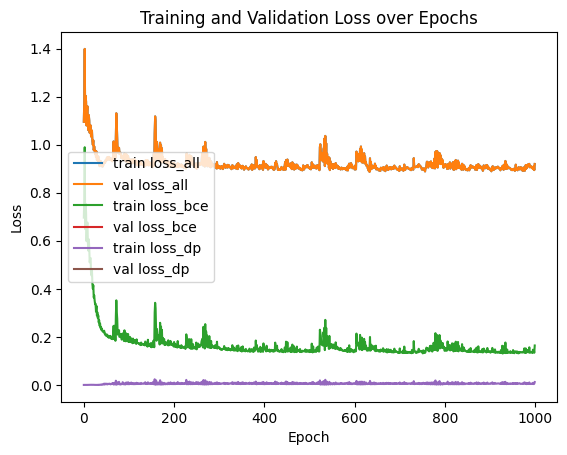

In [66]:
for metric in ['loss_all', 'loss_bce', 'loss_dp']:
    plt.plot(train_split['epoch'], train_split[metric], label=f'train {metric}')
    plt.plot(val_split['epoch'], val_split[metric], label=f'val {metric}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

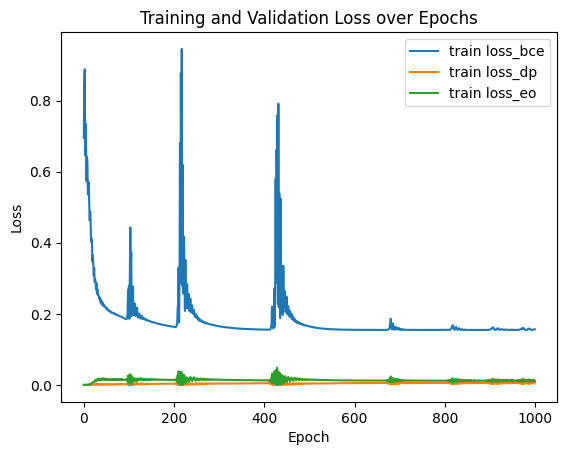

In [53]:
for metric in ["loss_bce", "loss_dp", "loss_eo"]:
    plt.plot(train_split['epoch'], train_split[metric], label=f'train {metric}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

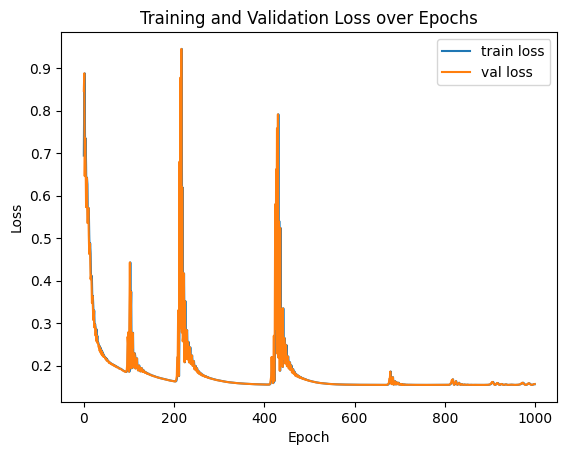

In [54]:
metric = "loss_bce"
plt.plot(train_split['epoch'], train_split[metric], label='train loss')
plt.plot(val_split['epoch'], val_split[metric], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

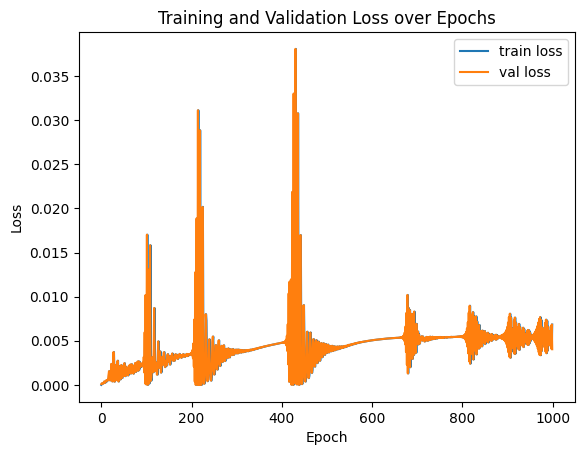

In [48]:
metric = "loss_dp"
plt.plot(train_split['epoch'], train_split[metric], label='train loss')
plt.plot(val_split['epoch'], val_split[metric], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

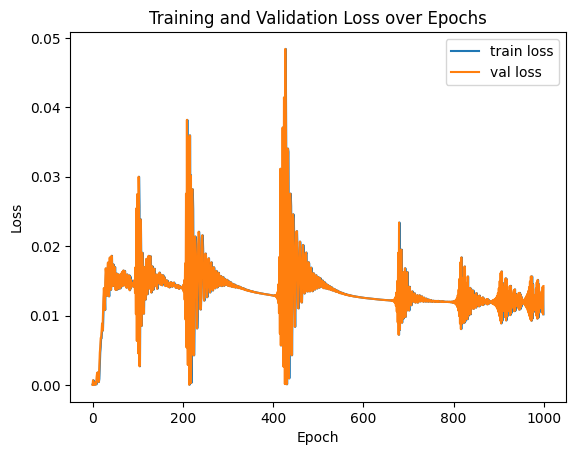

In [49]:
metric = "loss_eo"
plt.plot(train_split['epoch'], train_split[metric], label='train loss')
plt.plot(val_split['epoch'], val_split[metric], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

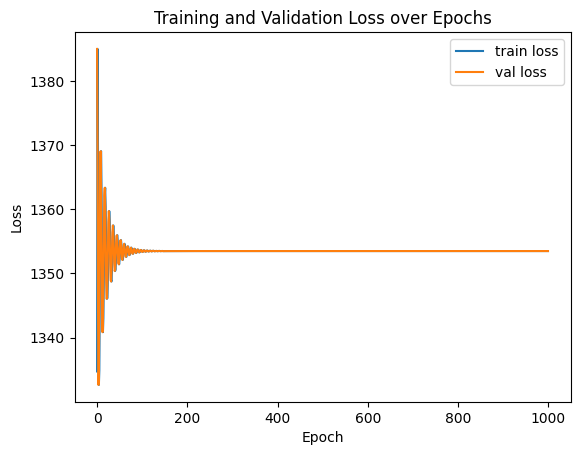

In [50]:
metric = "loss_l1"
plt.plot(train_split['epoch'], train_split[metric], label='train loss')
plt.plot(val_split['epoch'], val_split[metric], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()